# [20260620] -- Update: we have done the following for the VaR Market Risk Module
## 1. computed the capital Sigma to obtain the daily volatility for our target bond example. 
## 2. created a simple module to compute the modified duration, bond price and also the convexity.
## 3. we have created a simple bootstrapping module to compute the single tenor market yields to obtain the zero rates individually.
## 4. we have created an interpolation of the volatility and merged them with the zero rates, discount factor and market yields.

# What is remaining:
## 1. we need to start implementing the bootstrapping technique to actually get the interpolated tenors for our bond cashflows. 
## 1.5. we are still stuck in no.1 mainly because i had to ensure that the computation for the zero rates is following mathematical and financial convention. Once that was confirmed the rest was a bit more straightforward. 
## 1.5.1. one of the bigger issues right now that im facing is how do i create a constant medium cashflow dataframe that can sumproduct against the cashflows and the discount factor for each tenor. food for thought. we can continue on with this when we go home. 
## 2. once that is done we need to split and group the cashflows based on the tenor vertices following the bond market. once that is done we can finally compute the VaR and then we are almost done with an MAS 637 production grade interest rate risk for trading book capital requirements computation. 
## 3. i need to now label the cashflow from the bond cashflows that we have split into the bond market tenor vertices accordingly so that i can do the computation for the cashflow factorization. if anything please focus on this!!! --> IMPORTANT! 20260620.

## #------------- Read Me ------------------#
## 1. Import necessary libraries for the computation of VaR (Value-at-Risk)

In [ ]:
import pandas as pd
import numpy as np 
import os
from datetime import datetime, date
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
# create a discount factor class module.
def discount_factor_calculator(int_rate, m_freq, no):
    # df = (1/(int_rate/m_freq))^(no)
    disc_factor = (1/(1+(int_rate/m_freq)))**(no)
    return disc_factor



## 2. To create a simple example of a bond that has a notional of 10 million USD that receive coupon payments of 5% p.a. every semiannually for 10 years.
### This is equivalent to 20 total coupon payments across the span of 10 years.
### The code below is to compute the and aggregate the cashflows payments with its present value cashflows into a table (DataFrame)

### [Note: The discount factor computed here is on the assumption that the yield curve is uniform at 5% across the whole tenors of the bonds life.]

In [ ]:
notional = 10000000
coupon_rate = 0.05
int_rate = 0.05
m_freq = 2
time_t = 10
n = (time_t * m_freq)

# to compute the coupon cashflows we need to breakdown the cashflows 
# by tenor

coupon_amt = coupon_rate / 2 * notional
print(f"{coupon_amt:,.2f}")

#bond_cashflow_df = pd.DataFrame(columns = columns)
#bond_cashflow_df

no = []
tenor = []
coupon_cf = []
face_value = []
discount_factor = []

for i in range(1, n+1):
    print(i)
    # include number of payments
    no.append(i)
    # include the tenor 
    compute_tenor = i/m_freq
    tenor.append(compute_tenor)
    # include the coupon cashflows for every semi ann coupon
    coupon = coupon_rate/ m_freq * notional
    coupon_cf.append(coupon)
    # include the notional at the end of the tenor
    if i == n:
        face_value.append(notional)
    else:
        face_value.append(0)
    # compute the discount factor
    dis_fact = discount_factor_calculator(int_rate, m_freq, i)
    discount_factor.append(dis_fact)
        
bond_dict = {'no': no, 'tenor': tenor,
             'coupon_amt': coupon_cf, 
             'face_value': face_value,
            'df' : discount_factor}

bond_cf_df = pd.DataFrame.from_dict(bond_dict)
display(bond_cf_df)

## 3. We shall compute the following risk metrics for the bond. 
### a. DV01 - the change of the bonds price based on the change of the entire yield curve if it moves up by 1bps (0.001)
### b. Bond price - its the summation of the entire present value of the cashflows across the life of the bond to today divided by its notional. 
### c. Macaulay Duration - This is the breakeven tenor where the total cashflows match the return of investment of the bond. Since the final cashflow payment happens at the end of the tenor, the duration would normally be +/- 2 years from its maturity.
### d. Modified Duration - This is the percentage change in bond prices if the change in the yield curve goes up by 1bps.
### e. Bond Convexity - This captures the curvature of the bond at the longer end of the changes of the yield curve changes. Due to the nature of the bond, the modified duration can only capture the changes of the bond linearly when yield changes are small. but if a larger change of 100 bps (1%) it will significantly be unable to compute the correct approximations of the bond due to the curvature of the bond. this is where the convexity comes in. this confirms that concept that if the bond moves at higher yield differentials, it actually offsets the loss of the duration. 

### For comprehension, i will provide the formulas here for ease of reference. 

$ \Large \text{a. DV01 = Modified Duration } \times \text{Notional } \times \text{0.0001} $

$ \Large \text{b. Bond Price = } \displaystyle\sum_{t=1}^n \frac{\text{CF}_{t}}{{(1 + i)}^t} + \frac{{FV}_{n}}{{(1+i)}^n}  $

$ \Large\text{where:} $

$ \Large\text{CF: Coupon cashflows from time, t = 1 till n} $

$ \Large\text{FV: Face value of bond at time, t = n} $

$ \Large\text{n: Final tenor of the bond} $

$ \Large\text{i: interest rate for the entire bond.} $

$ \Large\text{c. Macaulay Duration = } \displaystyle\sum_{t=1}^n \frac{(t \times CF_{t})}{{(1 + i)}^t} + \frac{(n \times {FV}_{n})}{{(1 + i)}^n}  $

$ \Large\text{d. Modified Duration = } \frac{\text{Macaulay Duration}}{(1 + \frac{y}{m})}  $

$ \Large\text{e. Bond Convexity = } \frac{1}{Bond Price \times (1 + \frac{y}{m})^2} \displaystyle\sum_{t=1}^n \frac{(t \times (t + 1) \times CF_{t})}{(1+ \frac{y}{m})^t} $

$ \Large\text{f. change in convexity = } \frac{1}{2} \times \text{convexity} \times \text{notional} \times (\Delta y)^2  $

$ \Large\text{g. change in bond value = } \text{change in duration (DV01)} + \text{change in convexity}  $

In [ ]:
# compute the present value cashflow 
bond_cf_df['pv_cf'] = bond_cf_df['df'] * (bond_cf_df['coupon_amt'] + bond_cf_df['face_value'])

# compute the present_value x tenors to compute the modified duration. 
bond_cf_df['pv_cf2'] = bond_cf_df['pv_cf'] * bond_cf_df['tenor']

# compute the bond DV01
bond_cf_df['dv01'] = bond_cf_df['pv_cf'] * bond_cf_df['tenor'] * 0.0001

# compute the convexity of the bond.(t * (t+1) * pv_cf at tenor)/ (notional * (1 + (int_rate/2))^2) 
bond_cf_df['pv_cf_conv'] =  (bond_cf_df['tenor'] * (bond_cf_df['tenor'] + 1)) * bond_cf_df['pv_cf']
display(bond_cf_df)
bond_cf_df.dtypes

# compute the bond price 
bond_price = bond_cf_df['pv_cf'].sum() / notional
print(f"current bond price at interest rate of {int_rate} is: {bond_price:,.8f}")

# compute the macaulay duration
macaulay_duration = bond_cf_df['pv_cf2'].sum() / notional
print(f"macaulay duration for the bond portfolio is: {macaulay_duration:,.5f}")

# compute the modified duration
modified_duration = macaulay_duration/ (1+ (int_rate/m_freq))
print(f"modified duration for the bond portfolio is: {modified_duration:,.5f}")

# lets compute the dv01 for the entire bond 
dv01 = modified_duration * notional * 0.0001
print(f"dv01 for the entire bond portfolio is: {dv01:,.2f}")

# lets see what is the dv01 computed from the dataframe
dv01_df_cmpt = bond_cf_df['dv01'].sum()
print(f"dv01_df_cmpt is: {dv01_df_cmpt:,.2f}")

# computing the convexity of the bond portfolio
bond_convex = (bond_cf_df['pv_cf_conv'].sum() / (bond_price * (1 + (int_rate/m_freq))**2))/ notional
print(f"bond convexity of the portfolio is: {bond_convex:,.2f}")

# to compute the change in value now we have the modified duration and bond convexity.
delta_yield = 0.03
duration_only_change = (-1) * (modified_duration * notional * delta_yield)
convexity_only_change = ((0.5) * (bond_convex * notional * (delta_yield**2)))
change_value = (-1) * (modified_duration * notional * delta_yield) + ((0.5) * (bond_convex * notional * (delta_yield**2)))
print(f"change in value for the bond if the entire yield curve moves up by {delta_yield * 10000}bps is: {change_value:,.2f}")
print(f"breakdown of the change in value are as follows: \nduration only change is: {duration_only_change:,.2f}\nconvexity change only is: {convexity_only_change:,.2f}")


# compile the necessary information required for a risk analyst to assess the computed data. 

bond_risk_metrics = {'bond_price' : f"${bond_price * 100:,.2f}",
                    'macaulay_duration' : f"{macaulay_duration:.4f}",
                    'modified_duration' : f"{modified_duration:.4f}%",
                    'DV01' : f"${dv01:,.2f}",
                    'bond_convexity' : f"{bond_convex:.4f}",
                    'duration_change' : f"${duration_only_change:,.2f}",
                    'convexity_change' : f"${convexity_only_change:,.2f}",
                    'potential_change_value' : f"${change_value:,.2f}"}

# convert this to dataframe. 
bond_risk_metrics_df = pd.DataFrame.from_dict(bond_risk_metrics, orient = 'index', columns = ['risk_metrics'])
display(bond_risk_metrics_df)

# print a neat report for a risk analysis to assess properly. 
print("=" * 50)
print(f"#            BOND RISK & METRICS REPORT          #")
print("=" * 50)
print(f"{'Portfolio notional': <25} ${notional:,.2f}")
print(f"{'Annual coupon rate': <25} {coupon_rate * 100:.2f}%")
print(f"{'Yield to Maturity (YTM)': <25} {int_rate * 100:.2f}%")
print(f"{'Years to maturity': <25} {time_t:.2f} years")
print("-" * 50)
print(f"{'Calculated Market Bond Price': <25} ${bond_price*100:,.2f} ")
print("-" * 50)
print(f"{'Macaulay Duration': <25} {macaulay_duration:.4f} Years")
print(f"{'Modified Duration': <25} {modified_duration:.4f}%")
print(f"{'Convexity': <25} {bond_convex:.4f}")
print("-" * 50)
print(f"{'DV01 (Risk per 1 Bps Drop):':<25} ${dv01:,.2f}")
print("=" * 50)
print(f"#         SCENARIO ANALYSIS - RISK METRICS       #")
print("=" * 50)
print("-" * 50)
print(f"Bond Portfolio if yield curve moves up by {(delta_yield * 10000):.1f} bps.")
print("-" * 50)
print(f"{'DV01 of Bond Portfolio is': <25} ${duration_only_change:,.2f}.")
print(f"{'Convexity of Bond Portfolio is': <25} ${convexity_only_change:,.2f}.")
print(f"{'Change in value of Bond Portfolio is': <25} ${change_value:,.2f}.")
print("-" * 50)

$\Large\text{The below is just for educational purposes.}  $

$\Large\text{The goal was to check if the difference between the DV01 approximations if the yield curve changes at a higher magnitude.}  $

$\Large\text{Suffice to say that the bond principles still holds and the bond convexity computation is able to capture the shape of the bond curvature as the yield goes larger.}  $

In [ ]:
# let us graph the 10 year bond price vs. the yield movement to see if there is a curve.
# lets do a ytm of between the range of (0.05 to 0.1)
bond_price_list = []
ytm_list = []
dv01_change_list = []
convex_list = []

for i in np.arange(0.0005, 0.2005, 0.0005):
#    print(i.round(5))
    # create a dataframe for the targeted interest rate
    ytm_rate = pd.DataFrame(i, index = [j for j in range(n)], columns = ['ytm'])
#    print(display(ytm_rate))
    # left join the data with the bond_cf_df['no', 'tenor', 'coupon_amt', 'face_value']
    medium_df = ytm_rate.merge(bond_cf_df[['no','tenor', 'coupon_amt', 'face_value']], how = 'outer', left_index = True, right_index = True)
#    display(medium_df)
    # apply the discount factor for the ytm.
    # create a blank disc_fact_list to temporary store the discount factors for the target ytm.
    disc_fact_list = []
    for count in range(len(medium_df)):
#        print(f"count for second loop is: {count}")
#        print(f"tenor is: {display(medium_df.loc[count, 'tenor'])}")
#        print(f"target_ytm is: {medium_df.loc[count, 'ytm']}")
#        print(f"m_freq is: {m_freq}")
        disc_fact = discount_factor_calculator(medium_df.loc[count, 'ytm'], m_freq, medium_df.loc[count, 'tenor'])
#        print(f"disc_fact after computation of discount factor based on variables is: {disc_fact}")
        disc_fact_list.append(disc_fact)
#    print(f"disc_fact_list is: {disc_fact_list}")
    medium_df = medium_df.merge(pd.DataFrame(disc_fact_list, index = [j for j in range(n)], columns = ['disc_fact']), how = 'left', left_index = True, right_index = True)
#    print(f"medium_df after computing disc_fact_list is: {display(medium_df)}")
    # compute the pv_cf based on the discount factors computed. 
    medium_df['pv_cf'] = (medium_df['coupon_amt'] + medium_df['face_value']) * medium_df['disc_fact']
#    print(f"medium_df after computing pv_cf is: {display(medium_df)}")
    bond_price = (medium_df['pv_cf'].sum() / notional ) * 100
#    print(f"bond_price for ytm = {i} is: {bond_price}")
    # lets compute the dv01 + convexity of the bond 
    delta_yield = (0.05 - i/m_freq)
    dv01_change = (100) * modified_duration * delta_yield
    bond_convexity = (100) * (0.5) * bond_convex * (delta_yield ** 2)
    total_change = dv01_change + bond_convexity
    est_dv01_bond_price = 100 + (dv01_change*100)
#    print(f"bond duration and convexity metrics are as follows:")
#    print(f"for delta yield of: {delta_yield}:")
#    print(f"dv01_change: {dv01_change*100}")
#    print(f"est_dv01_bond_price is: {est_dv01_bond_price}")
#    print(f"bond_convexity: {bond_convexity}")
#    print(f"total_change: {total_change}")
    # lets collate the bond prices and the ytm 
    bond_price_list.append(bond_price)
    ytm_list.append(i)
    dv01_change_list.append(dv01_change)
    convex_list.append(bond_convexity)    
#    if i == 0.001:
#        break
    
bond_details_dict = {
    'ytm' : ytm_list,
    'bond_prices' : bond_price_list,
    'dv01_change' : dv01_change_list,
    'convexity' : convex_list
}

#print(f"bond_details_dict is: {bond_details_dict}")
# convert the data into pandas
bond_details_df = pd.DataFrame.from_dict(bond_details_dict, orient = 'index').T
#print(f"bond_details_df after putting into dataframe is: {display(bond_details_df)}")
# lets compute the total change of value for both bond prices for the dv01 and convexity. 
bond_details_df['par_value'] = 100
bond_details_df['bond_price_dv01_only'] = bond_details_df['par_value'] + bond_details_df['dv01_change']
bond_details_df['bond_price_all'] = bond_details_df['par_value'] + bond_details_df['dv01_change'] +  bond_details_df['convexity']
bond_details_df['ytm_new'] = bond_details_df['ytm']/ 2
#print(f"bond_details_df after computing the dv01 price and total change of the bond price is: {display(bond_details_df)}")
#print(f"bond_details_df after creating ytm_new is: {display(bond_details_df)}")
bond_details_df = bond_details_df.drop(columns = ['ytm']).rename(columns = {'ytm_new': 'ytm'})
#print(f"bond_details_df after renaming and dropping ytm is: {display(bond_details_df)}")
bond_details_df = bond_details_df[['ytm', 'bond_prices', 'bond_price_dv01_only', 'bond_price_all']]
print(display(bond_details_df))

# plot the graph for the YTM vs. the bond prices.
plt.figure(figsize = (10,6))
plt.plot(bond_details_df['ytm'] * 100, bond_details_df['bond_prices'], label = "Bond Prices Curve", color = 'blue', linewidth = 2.5)
# to plot in the graph for the linear approximation of the bond prices with only DV01 changes.
plt.plot(bond_details_df['ytm'] * 100, bond_details_df['bond_price_dv01_only'], label = "Bond Price DV01 Approximation", color= "green", linestyle = '--',
         linewidth = 2.5)

# to plot in the graph for the total bond changes approximation of the bond prices with both DV01 and bond convexity changes against the bonds actual curve.
plt.plot(bond_details_df['ytm'] * 100, bond_details_df['bond_price_all'], label = "Bond Price Complete Approximation (DV01 + Convexity)",
         color= "orange", linestyle = '--', linewidth = 2.5)

# fill in between the difference of the DV01 approximations vs. the actual curve.
plt.fill_between(bond_details_df['ytm'] * 100, bond_details_df['bond_price_dv01_only'], bond_details_df['bond_prices'], color = 'purple', 
                alpha = 0.15, label = "Convexity Effect (Error Gap)")

# plot the current market price of the bond. 
plt.scatter(5, 100, color = 'red', s = 100, zorder = 5, label = "Current Market State (5% YTM, $100)")
plt.axhline(100, color = 'gray', linestyle = '--', alpha = 0.5)
plt.axvline(5, color = 'gray', linestyle = '--', alpha = 0.5)

# add titles, labels and formatting
plt.title("Bond Prices: DV01 Approximation vs. Actual Curve", fontsize = 14, fontweight = "bold")
plt.xlabel("Yield to Maturity (%)", fontsize = 12)
plt.ylabel("Bond Prices ($)", fontsize = 12)
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.legend(fontsize = 11)
plt.show()

$\Large\text{The objective of the code below is to compute the following: } $

$\Large\text{a. to compute the sigma } {(\sum = Z^T Z )} $

$\Large\text{where: } $

$\Large Z =  \frac{1}{1-n}{(X - 1\mu)}$

$\Large\text{where:} $

$\Large\text {i. X is the actual data points for the 1 years worth of bond par yields} $

$\Large\text{ii. } \mu \text{ is the average of the entire time series for each of the tenors par yields} $

$\Large\text{iii. n is the number of trading days taken for the targeted time series snapshot.} $

$\Large\text{b. to compute the correlation matrix via formula, } \rho = D^{-1} \sum D $

$\Large\text{where: } $

$\Large\text{i. } D^{-1} \text{ is the diagonal standard deviations of the } \sum $

In [ ]:
# now lets go ahead and compute the Value at Risk for the targeted bond market. 
# we shall take the relevant tenors from the bond market for 1 trading year and then compute its correlation matrix. 
# lets extract the bond yields from the US treasury website.
# Update - [20260812]: I am here to correct a mistake.
# We cannot just simply interpolate the par yields. 
# We also need to bootstrap the par yields to obtain the zero rates. 
# so heres what we are going to do. 
# 1. create an interpolation of the tenors from start (1M) till end (30Y) with increments of 0.5 years.
# 2. then we create an algorithm to bootstrap the yields one by one until 30Y tenor. 
# 3. i think from there we can collapse the tenors into the market tenors prescribed by US treasury yields. 
# 4. And then we can compute the sigma (var-covar)


treasury_rates_2025_file_name = os.getcwd() + "\\daily-treasury-rates (2025).csv"
treasury_rates_2026_file_name = os.getcwd() + "\\daily-treasury-rates (2026).csv"

treas_2025_df = pd.read_csv(treasury_rates_2025_file_name)
treas_2026_df = pd.read_csv(treasury_rates_2026_file_name)

# append data
treas_df = pd.concat([treas_2025_df, treas_2026_df], axis = 0)

# capture the numerical values in each column string to compute its tenor by years.
tenor_list = [float(re.sub(r'[^0-9.]', '', col))/12 if "Mo" in col else float(re.sub(r'[^0-9.]', '', col)) for col in treas_df.columns.tolist() if col != 'Date']
print(f"tenor list is: {tenor_list}")

# rename columns. replace the gap to an underscore and then lower case all of them.
col_list = [col.replace(" ","_").lower() for col in treas_df.columns.tolist()]
treas_df.columns = col_list

# lets create a dictionary for the tenor_list (vals) + cols_list (keys)
tenor_dict = dict(zip(col_list[1:], tenor_list))
print(f"tenor_dict is now: {tenor_dict}")

# convert date into pandas format.
treas_df['date'] = pd.to_datetime(treas_df['date'], format = "%m/%d/%Y")

# sort the date from oldest to newest.
treas_df = treas_df.sort_values(by = ['date'], ascending = True)

# reset the index and then drop the old index. 
treas_df = treas_df.reset_index().drop(columns = ['index'])

print(f"treas_df after cols replace/ reset index and drop index is: \n {display(treas_df)}")

# we need to interpolate the 1.5 month bond yields as it is not available.
# based on what Gemini has told me it seems like it can be done onto the data itself. no transformation required.
target_cols = [col for col in treas_df.columns.tolist() if col != 'date']
treas_df2 = treas_df[target_cols].interpolate(axis = 1)
print(f"treas_df2 after interpolation of 1.5m tenor is:\n {display(treas_df2)}")


treas_df3 = treas_df2.merge(treas_df['date'], how = 'right', left_index = True, right_index = True)
treas_df3 = treas_df3[treas_df.columns.tolist()]  
print(f"treas_df3 after merging back with treas_df is:\n {display(treas_df3)}")

# lets export treas_df, treas_df2, and treas_df3
file_name = "treas_df.xlsx"
with pd.ExcelWriter(file_name) as writer:
    treas_df.to_excel(writer, sheet_name = "treas_df", index = True)
    treas_df2.to_excel(writer, sheet_name = "treas_df2", index = True)
    treas_df3.to_excel(writer, sheet_name = "treas_df3", index = True)
print(f"{file_name} has been exported to: ({os.getcwd()}\\{file_name})")

# lets get the yield changes diff from the data below. [lets only take the last 252 trading days for a full 1 year comparison]
treas_df4 = treas_df3.iloc[-252:,:] # we shall only take the last 252 trading days data points.
# lets reset the index and then sort the date by desc
#treas_df4 = treas_df4.reset_index()
#treas_df4 = treas_df4.sort_values(by = "date", ascending  = False)

print(f"treas_df4 after only taking in the last 252 trading days: \n {display(treas_df4)}")
# The below computes the diff between the yields for each days, x_{i, t-1}
treas_df5 = treas_df4[target_cols].diff().dropna()

print(f"treas_df5 is the diff data: \n {display(treas_df5)}")

In [ ]:
# we now need to bootstrap each date slice. 
treas_1_df = treas_df4.iloc[0,:]
tenor_dict['date'] = 'date'
print(f"tenor_dict is: {tenor_dict}")
print(f"tenor_dict length is: {len(tenor_dict)}")
print(f"treas_1_df.index length is {len(treas_1_df.index)}")
treas_1_df.index = treas_1_df.index.map(tenor_dict)
treas_1_df

In [ ]:
# now lets create an array or series for the 30 years with increments of 0.5 years
max_tenor = treas_1_df.index[len(treas_1_df.index)-1]
new_index = [i for i in np.arange(0.5, (max_tenor+0.5), 0.5)]
# print(treas_1_df.iloc[0])
treas_1_reindex_df = pd.DataFrame(index=new_index)
#print(f"treas_1_reindex_df is:\n {display(treas_1_reindex_df)}")

# keep the date for reference. 
target_date = treas_1_df.iloc[0]
print(f"target_date is: {target_date}")

# combine both the series and the new index to have the full tenor. 
# rename the treas_1_df.index.name = 'par_yields'
treas_1_df.index.name = 'par_yields'
combined_df = treas_1_reindex_df.join(treas_1_df.iloc[1:], how = 'outer').sort_index().rename(columns = {150: 'par_yields'})
print(f"combined_df is:\n {display(combined_df)}")
print(f"combined_df index is:\n {display(combined_df.index)}")
print(f"combined_df columns is:\n {display(combined_df.columns)}")

# define data as float
combined_df = combined_df.astype(float)

# interpolate the data. 
combined_df['par_yields'] = combined_df['par_yields'].interpolate(method = 'index')
print(f"combined_df after interpolation is: \n {display(combined_df)}")

# divide it by 100
combined_df['par_yields'] = combined_df['par_yields']/100
print(f"combined_df after dividing by 100 is:\n {display(combined_df)}")

# what we need to do right now is to split the tenors between anything <= 0.5 
# and whatever tenors that are >= 0.5. 
# we shall create a mod for that. 
combined_df['mod'] = np.isclose(combined_df.index % 0.5, 0).astype(int)
print(f"combined_df after modulo 0.5% is: \n {display(combined_df)}")

# 


In [ ]:
# lets compute the sigma first we need to compute the average mean for each tenor based on their yield diff. 

average_yield_by_tenor = treas_df5.mean()
print(f"mean across all tenors are: {average_yield_by_tenor}")
print(f"transpose of mean across all tenors are: {average_yield_by_tenor.T}")
print(f"shape of mean across all tenors is: {average_yield_by_tenor.shape}")

# we now will have to create a series of 1's vectors with a shape of [252,1]
vector_1_df = treas_df5.copy()
vector_1_df['vector_1s'] = 1
vector_1_df = vector_1_df['vector_1s'].astype(float)
print(display(vector_1_df))

print(f"vector_1_df is: {vector_1_df.values}")
print(f"vector_1_df shape is: {vector_1_df.values.shape}")
#print(f"vector_1_df reshape is: {vector_1_df.values.reshape(-1,1)}")
print(f"vector_1_df reshape shape is: {vector_1_df.values.reshape(-1,1).shape}")
print(f"average_yield_tenor is: {average_yield_by_tenor.values}")
print(f"average_yield_tenor shape is now: {average_yield_by_tenor.values.shape}")
print(f"average_yield_tenor reshape is: {average_yield_by_tenor.values.reshape(1,-1)}")
print(f"average_yield_tenor reshape shape is now: {average_yield_by_tenor.values.reshape(1,-1).shape}")

# we shall now do a simple dot product of vector 1s  @ X't [254 x 1] x [1 x 14] 

matrix_1u = vector_1_df.values.reshape(-1,1) @ average_yield_by_tenor.values.reshape(1,-1)
print(f"matrix_1u is: {display(matrix_1u)}")
print(f"matrix_1u shape is: {display(matrix_1u.shape)}")
print(f"matrix_1u data type is: {(type(matrix_1u))}")

# lets convert everything to numpy, its easier to dot product the data. 
# X - 1u
X = treas_df5.values
Z = X - matrix_1u

print(f"X is: {X}")
print(f"X shape is: {X.shape}")
print(f"Z is: {Z}")
print(f"Z shape is: {Z.shape}")

# lets compute the capital Sigma [1/ (n-1) x Z'Z]
n_rows = len(Z) - 1
sigma = (Z.T @ Z)/ (n_rows)
print(f"sigma is now: {display(sigma)}")
print(f"sigma shape is now: {display(sigma.shape)}")

# lets find the std_dev for the diagonals of the sigma matrix.
D = sigma ** (0.5)
#D = np.sqrt(np.clip(D, 0, None))
D = np.diag(np.diag(D))
print(f"D is {D}")

# minverse the D
D_inv = np.linalg.inv(D)
print(f"D_inv is : {D_inv}")

# lets get the correlation matrix up and running [D-1 x E x D-1]
corr_matrix_manual = D_inv @ sigma @ D_inv

# convert corr_matrix_manual into DataFrames
corr_matrix_man_df = pd.DataFrame(corr_matrix_manual, index = target_cols, columns = target_cols)
print(f"the correlation matrix is below!")
print(f"corr_matrix_man_df is: {display(corr_matrix_man_df)}")
print(f"the correlation matrix is above!")

# convert it to pandas to visualization 
sigma_df = pd.DataFrame(sigma, index = target_cols, columns = target_cols)
print(f"sigma_df is: {display(sigma_df)}")

In [ ]:
# lets create a heatmap so that we can check out any multicollinearity for the 14 tenors.
# create a heat map
# 1. plot figure by defining it first.

plt.figure(figsize = (8,6))

# 2. define the heatmap using sns 
sns.heatmap(
    corr_matrix_man_df,
    annot = True,              # displays the correlation numbers inside each square
    cmap = 'coolwarm',         # color gradient (blue for negative, red for positive)
    fmt = '.2f',               # formats the numerical values into 2 decimals.
    vmin = -1, vmax = 1,       # sets anchor bounds for color bar.
    linewidth = 0.5            # creates a thin line for scanability.
)

# 3. Add titles and show plot
plt.title('Correlation Matrix Heatmap', fontsize = 14, pad = 15)
plt.tight_layout()
plt.show()



# Just to confirm that these rates that are posted by the US treasury website are actually semi annual rates. 
# Meaning to bootstrap we will need to annualize the yields before we convert them to zero rates. 
# Please refer to the snapshot below for an excerpt of the answers asked in the FAQ section of the US Treasury website. 

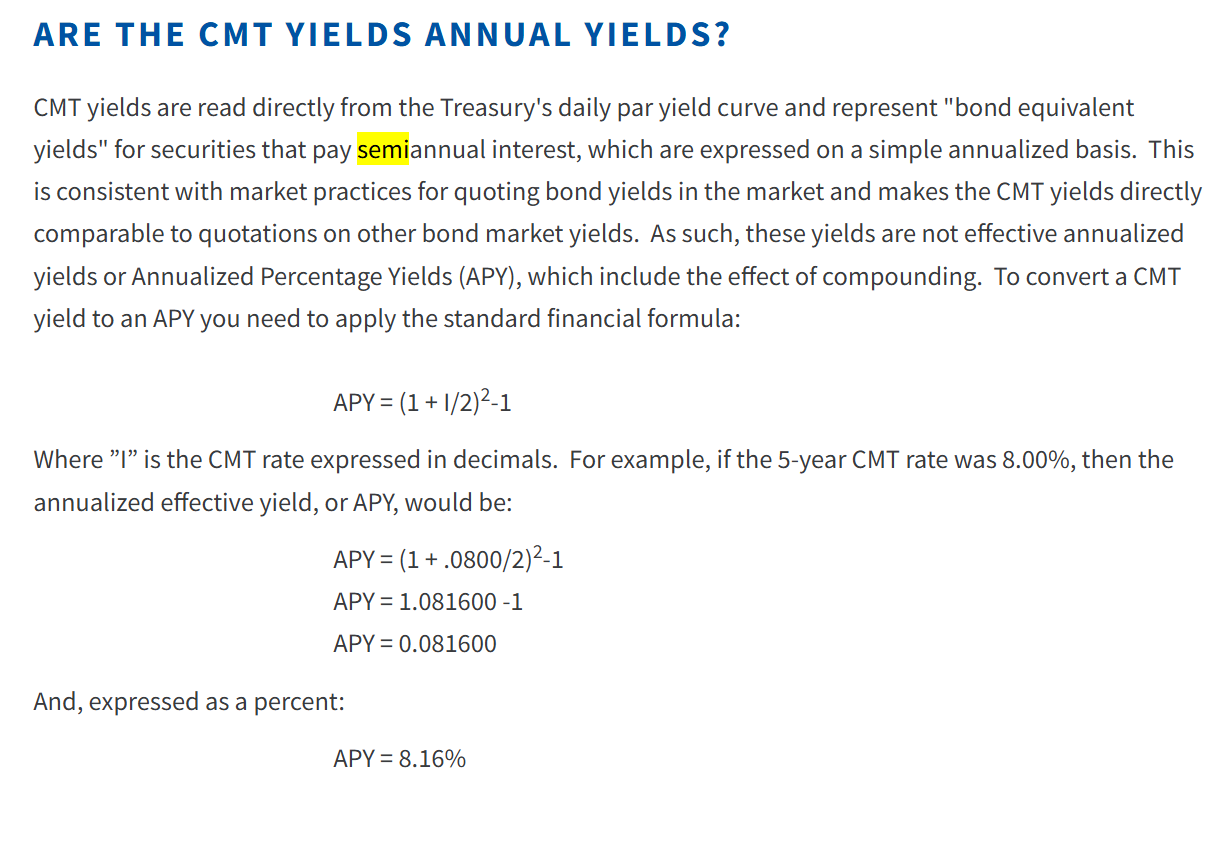

In [ ]:
# we now need to do the bootstrapping first. 
display(bond_cf_df)

# we need to get the last dated par yields from the US treasury date.
latest_yields_df = treas_df3.iloc[-1,:].to_frame()
latest_yields_df = latest_yields_df.rename(columns = {0 : 'mkt_yields'})

#print(display(latest_yields_df))

#print(target_cols, tenor_list)

date_value = latest_yields_df.iloc[0,0]

#print(f"date_value is: {display(date_value)}")

# define the values for the dataframe
all_values = [date_value] + tenor_list
print(f"all_values after including date_value is: {display(all_values)}")

# As of [20260617] #
# Ben - I have created a full bond tenor 
# lets also merge the latest_yields_df with the tenors.
latest_yields_df = pd.concat([latest_yields_df, pd.DataFrame(all_values, index = latest_yields_df.index, columns = ['tenors'])], axis = 1)
print(f"latest_yields_df after including tenors columns is: {display(latest_yields_df)}")

# max tenor for list?
max_tenor = max(all_values[1:])
print(f"max_tenor for all_values list is: {max_tenor}")

new_tenors_list = []
# create a list range.
for tenor in np.arange(0.5, (max_tenor + 0.5), 0.5):
# check if tenors already exist if they do we dont need to append them in. 
    if tenor in all_values:
        print(f"target tenor value already exist: {tenor}")
    else:
        new_tenors_list.append(tenor)
    
print(f"new_tenors_list is: {new_tenors_list}")

joined_tenors_list = all_values[1:] + new_tenors_list
joined_tenors_list.sort()
print(f"joined_tenors_list is: {joined_tenors_list}")

final_values = [all_values[0]] + joined_tenors_list
print(f"final_values is: {final_values}")

bond_market_tenor_df_test = pd.DataFrame(final_values, columns = ['bond_market_tenor'])
print(f"bond_market_tenor_df with final_values is: {display(bond_market_tenor_df_test)}")

print(f"latest_yields_df is: {display(latest_yields_df)}")

# join the bond_market_tenor_df_test to the latest_yields_df
total_bond_data_df = bond_market_tenor_df_test.iloc[1:,:].merge(latest_yields_df.iloc[1:,:], how = 'outer', left_on = ['bond_market_tenor'], right_on = ['tenors'])
print(f"total_bond_data_df is below here!")
print(f"total_bond_data_df is: {display(total_bond_data_df)}")
print(f"total_bond_data_df is above here!")

# merge the tenors together to combine them. 
total_bond_data_df['comb_tenors'] = np.where(total_bond_data_df['tenors'].isna(), total_bond_data_df['bond_market_tenor'], total_bond_data_df['tenors'])
print(f"total_bond_data_df is below here!")
print(f"total_bond_data_df['comb_tenors'] is now: {display(total_bond_data_df)}")
print(f"total_bond_data_df is above here!")

# remove the other two tenors. 
total_bond_data_df = total_bond_data_df.drop(columns = ['tenors', 'bond_market_tenor'])

# arrange the columns 
total_bond_data_df = total_bond_data_df[['comb_tenors', 'mkt_yields']].sort_values(by = ['comb_tenors'], ascending  = True)

# divide the par yields into actual percentage form
total_bond_data_df['mkt_yields'] = total_bond_data_df['mkt_yields']/ 100

# interpolate the par yields before you start bootstrapping them 
total_bond_data_df['mkt_yields'] = total_bond_data_df['mkt_yields'].infer_objects(copy=False).interpolate(method = 'linear')

# now that we have the interpolated par yields, we need to start bootstrapping them. 
# as mentioned in the US Treasury statement in its FAQs section. the CMT yields are based on semiannual rates. meaning that we have to annualize the 
# yields which are increments of 0.5 years by the power of 2 to get the accurate rates to bootstrap. 
# link is here for reference. [link: https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/interest-rates-frequently-asked-questions]
total_bond_data_df['semi_ann_tenor_flag'] = total_bond_data_df['comb_tenors'] % 0.5 
print(f"total_bond_data_df is: {display(total_bond_data_df)}")
display(total_bond_data_df)

def bootstrapping_single_yield(market_yield, tenor):  # this is wrong, for tenors shorter than 6 months the zero rates are equal to the par yields. we need to fix this.
    
    # first off, we need to establish the fact that the market yields for future value computations will equal to the zero rates. 
    future_value = 100 * ((1 + market_yield/2) ** (2 * tenor))
    discount_factor = 100 / future_value
#    print(f"computing tenor: {tenor}")
#    print(f"future_value is: {future_value}")
#    print(f"discount_factor is: {discount_factor}")
    
    power_tenor = tenor * 2 
#    print(f"power_tenor is: {power_tenor}")
    zero_rate = (((1/discount_factor)**(1/power_tenor))-1) * 2
#    print(f"zero_rate is: {zero_rate}")
#    freq = (1/tenor)
#    market_yield = (((1 + market_yield/2)** (power_tenor))- 1) * freq # due to the market yields actually being quoted semiannually.
    
    return zero_rate, discount_factor

def zero_rates_computation(discount_factor, tenor, freq):
    
    power_tenor = tenor * freq
    zero_rate = (((1/discount_factor)**(1/power_tenor))-1) * freq
    
    return zero_rate

bond_single_tenor_df = total_bond_data_df.loc[total_bond_data_df['semi_ann_tenor_flag'] > 0].copy()
    
bond_single_tenor_df[['zero_rates', 'disc_factor']] = bond_single_tenor_df.apply(
    lambda row: bootstrapping_single_yield(row['mkt_yields'], row['comb_tenors']),
axis = 1, result_type = 'expand')
print(f"bond_single_tenor_df after using expand in lambda: {display(bond_single_tenor_df)}")
display(bond_single_tenor_df)
print(f"bond_single_tenor_df column names are: {display(bond_single_tenor_df.columns)}")
#bond_single_tenor_df[['zero_rates', 'disc_factor']] = pd.DataFrame(bond_single_tenor_df[('zero_rates', 'disc_factor')].tolist(), index = bond_single_tenor_df.index)
# drop the tuple '(zero_rates, disc_factor)'
#bond_single_tenor_df = bond_single_tenor_df.drop(columns = [('zero_rates', 'disc_factor')])

#display(bond_single_tenor_df)
#print(f"bond_single_tenor_df columns are: {display(bond_single_tenor_df.columns)}")


# we now need to compute the bootstrapping for the semiannual par yields in a continuous manner. 
bond_semi_ann_tenor_df = total_bond_data_df.loc[total_bond_data_df['semi_ann_tenor_flag'] == 0].copy()
display(bond_semi_ann_tenor_df)


## We need to figure our how do we compute that cashflow x DF for each period as we go further towards the maturity. 
## For example, we need to ensure that the DF is computed based on the entire cashflow tenors. 
## If tenor is at 1.5 years, our DF = [100 - sumproduct(all coupon cashflows multiply by their discount factor)]/ [C (maturity amount)]

In [ ]:
zero_rates_list = []
disc_fact_list = []
tenors_list = []

for i in range(len(bond_semi_ann_tenor_df)):
#    print(i)
    if i == 0:
        # lets define the following variables: [par_yield, tenor]
        par_yield = bond_semi_ann_tenor_df.iloc[i,1]
        semi_ann_par_yield = (par_yield / 2)  # frequency may differ. will hard code it for now. please make sure to make it dynamic. 
        target_tenor = bond_semi_ann_tenor_df.iloc[i,0]
        # lets find the discount factor since it has already factored in the tenor.
#        print(f"semi_ann_par_yield is: {semi_ann_par_yield}")
        discount_factor = (100/ (100 +  (100 * semi_ann_par_yield)))
        target_discount_rate = (1 / discount_factor)
        #target_zero_rate = bootstrapping_single_yield(par_yield, target_tenor)
#        print(f"following variables are as follows before we input them into the zero_rates_comp module:\n")
#        print(f"discount_factor = {discount_factor}\n")
#        print(f"target_tenor = {target_tenor}\n")
#        print(f"expected computation of zero rates is:\n")
#        print(f"discount rate = {1/discount_factor}\n")
#        print(f"power_tenor by semiann convention = {target_tenor * 2}")
        target_zero_rate = zero_rates_computation(discount_factor, target_tenor, 2) # as established from the screenshot above taken from the US treasury website, these yields are semi-annual 
#        print(discount_factor)
#        print(target_zero_rate)
        zero_rates_list.append(target_zero_rate)
        disc_fact_list.append(discount_factor)
        tenors_list.append(target_tenor)
    else: 
        # we need to create a simple cashflow table to compute the previous coupon payments based on their respective discount factors.
        # lets obtain the coupon payment for the targeted tenor first (i.e.: if the tenor is 1 then we need to have a length of 2 payments [0.5 and 1.0]) 
        par_yield = bond_semi_ann_tenor_df.iloc[i,1]
        semi_ann_par_yield = (par_yield/2)
        target_tenor = bond_semi_ann_tenor_df.iloc[i,0]
#        print(f"target_tenor is: {target_tenor}")
        coupon_payment = 100 * semi_ann_par_yield
        new_dict = {
            "tenors" : tenors_list,
            "disc_factors" : disc_fact_list
        }
        new_df = pd.DataFrame(new_dict)
        new_df['cpn_amt'] = coupon_payment
        new_df['pv_cf'] = new_df['disc_factors'] * new_df['cpn_amt']
#        print(f"new_df is: {display(new_df)}")
        # take the sum of all the pv_cf 
        sum_df_cf = new_df['pv_cf'].sum()
        discount_factor = (100 - sum_df_cf)/ (100 + (100 * semi_ann_par_yield))
        target_zero_rate = zero_rates_computation(discount_factor, target_tenor, 2)
#        print(f"sum_df_cf is: {sum_df_cf}")
#        print(f"discount_factor is: {discount_factor}")
#        print(f"target_zero_rate is: {target_zero_rate}")
        zero_rates_list.append(target_zero_rate)
        disc_fact_list.append(discount_factor)
        tenors_list.append(target_tenor)
                        
#print(zero_rates_list, disc_fact_list, tenor_list)
#print(f"length of the following lists are:\n")
#print(f"zero_rates length: {len(zero_rates_list)}")
#print(f"disc_fact_list length: {len(disc_fact_list)}")
#print(f"tenors_list length: {len(tenors_list)}")

# create a dictionary for the entire lists that you have for zero rates, discount factors and tenor list. 
all_computed_rates_dict = {"tenor" : tenors_list,
                          "disc_factor" : disc_fact_list,
                          "zero_rates" : zero_rates_list}

rates_df = pd.DataFrame(all_computed_rates_dict)
#display(rates_df)

# lets merge it with bond_semi_ann_tenor_df market yields.
rates_df2 = rates_df.merge(bond_semi_ann_tenor_df[['comb_tenors', 'mkt_yields']], how = 'left', left_on = ['tenor'], right_on = ['comb_tenors'])
rates_df2 = rates_df2.drop(columns = ['comb_tenors'])
display(rates_df2)

# append the bond_single_df zero rates along with the bond_single_tenor_df for a complete time series. 
display(bond_single_tenor_df.columns)
print(f"rates_df2 columns names are: {display(rates_df2.columns)}")
bond_single_tenor_df = bond_single_tenor_df[['comb_tenors', 'disc_factor', 'zero_rates', 'mkt_yields']]
# rename the comb_tenors to tenors
bond_single_tenor_df = bond_single_tenor_df.rename(columns = {'comb_tenors' : 'tenor'})
print(f"bond_single_tenor_df after renaming columns: {display(bond_single_tenor_df)}")
# append the data accordingly. 
rates_df2 = pd.concat([rates_df2, bond_single_tenor_df], axis = 0).sort_values(by = ['tenor'], ascending = True)
display(rates_df2)


In [ ]:
# what we are doing now is to now go back to the volatility and then interpolate it so that we can later do the 
# complex assignment of the cashflows if it falls at an irregular period.
type(sigma)
print(len(col_list[1:]))
display(latest_yields_df['tenors'].to_list()[1:])
tenor_list = latest_yields_df['tenors'].tolist()[1:]
sigma_df = pd.DataFrame(sigma, index = col_list[1:], columns = col_list[1:] )
display(sigma_df)
D
std_dev = np.diag(D)
print(std_dev)
std_dev_df = pd.DataFrame(std_dev, index = latest_yields_df[1:].index,  columns = ['std_dev'])
display(std_dev_df)

# left join the std_dev_df with the latest_yields_df.
std_dev_df2 = std_dev_df.merge(latest_yields_df['tenors'], how = 'left', left_index = True, right_index = True)
std_dev_df2 = std_dev_df2[['tenors', 'std_dev']]
display(std_dev_df2)

# lets left join the std_dev_df2 into the rates_df2
bond_vol_rates_df = rates_df2.merge(std_dev_df2, how = 'left', left_on = ['tenor'], right_on = ['tenors'])
# drop the tenors from std_dev_df2
bond_vol_rates_df = bond_vol_rates_df.drop(columns = ['tenors'])
# interpolate the volatility based on tenors. 
bond_vol_rates_df['std_dev'] = bond_vol_rates_df['std_dev'].interpolate(method = 'linear')

print(f"bond_vol_rates_df after interpolation is: {display(bond_vol_rates_df)}")

latest_yields_df['tenors'].tolist()[1:]

# filter only the tenors determined in the bond market tenor vertices
bond_vol_rates_df2 = bond_vol_rates_df[bond_vol_rates_df['tenor'].isin(latest_yields_df['tenors'].tolist()[1:])]
display(bond_vol_rates_df2)

In [ ]:
display(bond_vol_rates_df)

# we can finally compute the cashflow factorization by splitting the cashflows based on the bond market data based on their volailities. 
bond_cf_df2 = bond_cf_df[['no', 'tenor', 'coupon_amt', 'face_value']]
display(bond_cf_df2)

# lets first left join the bond_cf_df2 via tenors for the computed interpolated volatility for the specific tenor. 
bond_cf_std_dev_df = bond_cf_df2.merge(bond_vol_rates_df[['tenor','std_dev','disc_factor']], how = 'left', right_on = ['tenor'], left_on = ['tenor'])
display(bond_cf_std_dev_df)

# left join the tenor against the bond cf bond tenor
print(f"bond_vol_rates_df2 is: {display(bond_vol_rates_df2)}")
# rename the bond_vol_rates_df2 tenor into bond_market_tenors
# keep only the tenor.
bond_vol_rates_df3 = bond_vol_rates_df2[['tenor']]
bond_vol_rates_df3 = bond_vol_rates_df3.rename(columns = {'tenor': 'bond_market_tenor'})
full_bond_cf_df = bond_cf_std_dev_df.merge(bond_vol_rates_df3, how = 'left' , left_on = ['tenor'], right_on = ['bond_market_tenor']).rename(columns = {'bond_market_tenor': 'bond_tenor_upper_bound'})
full_bond_cf_df['bond_tenor_lower_bound'] = full_bond_cf_df['bond_tenor_upper_bound']
full_bond_cf_df['bond_tenor_lower_bound'] = full_bond_cf_df['bond_tenor_lower_bound'].infer_objects(copy = False).ffill()
full_bond_cf_df['bond_tenor_upper_bound'] = full_bond_cf_df['bond_tenor_upper_bound'].infer_objects(copy = False).bfill()
full_bond_cf_df = full_bond_cf_df.rename(columns = {'std_dev': 'interp_std_dev'})

# left join the full_bond_cf_df with the bond_vol_rates_df2 to get the standard volatilities computed from the sigma matrix. 
full_bond_cf_df = full_bond_cf_df.merge(bond_vol_rates_df2[['tenor','std_dev']], how = 'left', left_on = ['bond_tenor_upper_bound'], right_on = ['tenor']).drop(columns = ['tenor_y']).rename(columns = {'tenor_x': 'tenor', 'std_dev': 'std_dev_upper_bound'})
full_bond_cf_df = full_bond_cf_df.merge(bond_vol_rates_df2[['tenor','std_dev']], how = 'left', left_on = ['bond_tenor_lower_bound'], right_on = ['tenor']).drop(columns = ['tenor_y']).rename(columns = {'tenor_x': 'tenor','std_dev': 'std_dev_lower_bound'})
display(full_bond_cf_df)

display(corr_matrix_man_df)
print(f"corr_matrix_man_df index is: {display(corr_matrix_man_df.index)}")
print(f"corr_matrix_man_df columns is: {display(corr_matrix_man_df.columns)}")
# replace the index and the column names with the actual tenors. 
corr_matrix_man_df2 = corr_matrix_man_df.copy()
corr_matrix_man_df2.columns = bond_vol_rates_df2['tenor'].tolist()
corr_matrix_man_df2.index = bond_vol_rates_df2['tenor'].tolist()
display(corr_matrix_man_df2)
print(f"corr_matrix_man_df2 index is: {display(corr_matrix_man_df2.index)}")
print(f"corr_matrix_man_df2 columns is: {display(corr_matrix_man_df2.columns)}")

# create a correlation column
#target_correl_list = []
target_correl_list = [corr_matrix_man_df2.loc[full_bond_cf_df.loc[i,'bond_tenor_lower_bound'], full_bond_cf_df.loc[i,'bond_tenor_upper_bound']] for i in range(len(full_bond_cf_df))]
print(f"target_correl is: {target_correl_list}")

correl_df = pd.DataFrame(target_correl_list, columns = ['correl'])
full_bond_cf_df = pd.concat([full_bond_cf_df, correl_df ], axis = 1)

print(f"full_bond_cf_df is below here!")
print(f"full_bond_cf_df is: {display(full_bond_cf_df)}")
print(f"full_bond_cf_df is above here!")

# create a class module for the variance preservation principle. 
def variable_abc(std_dev_a, std_dev_b, correl_ab, interp_vol):
    var_a = std_dev_a**2 + std_dev_b**2 - 2*correl_ab*std_dev_a*std_dev_b
    var_b = 2 * correl_ab * std_dev_a * std_dev_b - 2 * (std_dev_b **2)
    epsilon = 1e-8
    discriminant = max(epsilon, (std_dev_b ** 2) - (interp_vol**2))
    var_c = discriminant
    
    var_c = (std_dev_b ** 2) - (interp_vol **2)
    print(f"var_c is: {var_c}")
    
    if var_a == 0 :
        var_a = 1
        var_b = 1
    
    return var_a, var_b, var_c

def quadratic_equation(a, b, c):
    
    inner_discriminant = (b**2 - 4*a*c)
#    print(f"inner_discriminant is: {inner_discriminant}")
    
    root_minus = (-b - np.sqrt(b**2 - 4*a*c))/ (2 * a)
    root_plus = (-b + np.sqrt(b**2 - 4*a*c))/ (2 * a)
    
#    print(f"root_minus is: {root_minus}")
#    print(f"root_plus is: {root_plus}")
    
    if 0.0 <= root_minus <= 1.0:
        return root_minus
    elif 0.0 <= root_plus <= 1.0:
        return root_plus

def all_combined_quad_eq(std_dev_a, std_dev_b, correl_ab, interp_vol):
    var_a, var_b, var_c  = variable_abc(std_dev_a, std_dev_b, correl_ab, interp_vol)
    scale_factor = quadratic_equation(var_a, var_b, var_c)
    return scale_factor

i = 1

#var_a, var_b, var_c = variable_abc(full_bond_cf_df.iloc[i,8], full_bond_cf_df.iloc[i,7], full_bond_cf_df.iloc[i,9], full_bond_cf_df.iloc[i,4])
#scale_alpha = quadratic_equation(var_a, var_b, var_c)
#print(f"var_a, var_b and var_c are as follows: {var_a, var_b, var_c}")
#print(f"data type for var_a is: {type(var_a)}")
#print(f"scale_alpha is: {scale_alpha}")

#scale_alpha_factor = all_combined_quad_eq(full_bond_cf_df.iloc[i,8], full_bond_cf_df.iloc[i,7], full_bond_cf_df.iloc[i,9], full_bond_cf_df.iloc[i,4])
#print(f"scale_alpha_factor is: {scale_alpha_factor}")

#full_bond_cf_df[['var_a', 'var_b', 'var_c']] = full_bond_cf_df.apply(
#    lambda row: variable_abc(row.iloc[8], row.iloc[7], row.iloc[9], row.iloc[4]),
#axis = 1,
#result_type = 'expand')
#print(f"full_bond_cf_df after implementing variables_abc module is: {display(full_bond_cf_df)}")

#var_abc_list = [variable_abc(full_bond_cf_df.iloc[i,8], full_bond_cf_df.iloc[i,7], full_bond_cf_df.iloc[i,9], full_bond_cf_df.iloc[i,4])
#                           for i in range(len(full_bond_cf_df))]

#var_a, var_b, var_c = zip(*var_abc_list)
#print(f"var_abc_list is: {var_abc_list}")
#print(f"var_a, var_b and var_c are: {var_a, var_b, var_c}")

scale_alpha_factor_list = [all_combined_quad_eq(full_bond_cf_df.loc[i,'std_dev_lower_bound'], full_bond_cf_df.loc[i,'std_dev_upper_bound'], full_bond_cf_df.loc[i,'correl'], full_bond_cf_df.loc[i,'interp_std_dev'])
                           for i in range(len(full_bond_cf_df))]

print(f"scale_alpha_factor_list is: {scale_alpha_factor_list}")

full_bond_cf_df = pd.concat([full_bond_cf_df, pd.DataFrame(scale_alpha_factor_list, columns = ['scale_alpha_factor'])], axis = 1)

# we are now going to compute the weighted variance split computed against the cashflow for the bond portfolio. 
full_bond_cf_df['pv_cf'] = full_bond_cf_df['disc_factor'] * full_bond_cf_df['coupon_amt']
full_bond_cf_df['weighted_cf_lower_bound'] = full_bond_cf_df['scale_alpha_factor'] * full_bond_cf_df['pv_cf']
full_bond_cf_df['weighted_cf_upper_bound'] = (1 - full_bond_cf_df['scale_alpha_factor']) * full_bond_cf_df['pv_cf']
print(f"full_bond_cf_df is: {display(full_bond_cf_df)}")

# we now need to sum up the data based on the weighted average we have computed for it. 
bond_weighted_upper_cf = full_bond_cf_df[['bond_tenor_upper_bound', 'weighted_cf_upper_bound']].rename(columns = {'bond_tenor_upper_bound': 'bond_market_tenor',
                                                                                                                 'weighted_cf_upper_bound' : 'weighted_pv_cf'})
bond_weighted_lower_cf = full_bond_cf_df[['bond_tenor_lower_bound', 'weighted_cf_lower_bound']].rename(columns = {'bond_tenor_lower_bound': 'bond_market_tenor',
                                                                                                                 'weighted_cf_lower_bound' : 'weighted_pv_cf'})
total_bond_weighted_cf = pd.concat([bond_weighted_upper_cf, bond_weighted_lower_cf])

# group by the market bond tenor
total_bond_weighted_cf = total_bond_weighted_cf.groupby('bond_market_tenor', as_index = False)['weighted_pv_cf'].sum()

# left join the total_bond_weighted_cf with the std_dev_df2
total_bond_weighted_cf = total_bond_weighted_cf.merge(std_dev_df2['tenors'], how = 'right', left_on = ['bond_market_tenor'], right_on = ['tenors']).drop(columns = ['bond_market_tenor']).rename(columns = {'tenors' : 'bond_market_tenor'})
total_bond_weighted_cf = total_bond_weighted_cf[['bond_market_tenor', 'weighted_pv_cf']]
total_bond_weighted_cf['weighted_pv_cf'] = total_bond_weighted_cf['weighted_pv_cf'].fillna(0)
print(f"total_bond_weighted_cf after left join is: {display(total_bond_weighted_cf)}")

print(f"std_dev_df2 is: {display(std_dev_df2)}")
print(f"shape of std_dev_df2 is: {display(std_dev_df2.shape)}")
print(f"total_bond_weighted_cf is: {display(total_bond_weighted_cf)}")

In [ ]:
# We can now compute the VaR against the correlation matrix with the weighted_pv_cf table. 
# lets first set the total_bond_weighted_cf as an index for the bond_market_tenor. 
total_bond_weighted_cf.index = total_bond_weighted_cf['bond_market_tenor']
total_bond_weighted_cf2 = total_bond_weighted_cf.drop(columns = ['bond_market_tenor'])
display(total_bond_weighted_cf2)

# convert the pandas dataframe into numpy
total_bond_weighted_values = total_bond_weighted_cf2.values
print(f"total_bond_weighted_values is: {total_bond_weighted_values}")

print(f"shape of sigma covariance variance matrix is: {sigma_df.shape}")
print(f"shape of total_bond_weighted_values is: {total_bond_weighted_values.shape}")
print(f"shape of total_bond_weighted_values.T is: {total_bond_weighted_values.T.shape}")

# formula to compute the portfoliow variance is (W' x E x W)
port_variance = total_bond_weighted_values.T @ sigma @ total_bond_weighted_values
print(f"port_variance is: {display(port_variance)}")

# divide the port_variance by 10000 due to the sigma matrix being in decimal factors rather than bps factor.
port_variance = port_variance/ 10000

# square root the portfolio variance. 
port_variance_sqrt = np.sqrt(port_variance)
print(f"port_variance_sqrt is: {display(port_variance_sqrt)}")

# compute the Value-at-Risk using confidence interval level of 99% (z-score ~ 2.33)
confidence_level = 0.99
no_of_days = 10
z_score = stats.norm.ppf(confidence_level)

VaR = port_variance_sqrt * z_score 
VaR_10_day = VaR * np.sqrt(no_of_days)
print(f"Value-at-Risk for bond with notional of 10 mio is: {VaR_10_day}")

# lets take a look at these numbers. 
with pd.ExcelWriter("weighted_cf_bond.xlsx") as writer:
    total_bond_weighted_cf.to_excel(writer, sheet_name = "weighted_cf", index = True)
    sigma_df.to_excel(writer, sheet_name = 'correl_matrix', index = True)
print(f"weighted_cf_bond.xlsx has been exported to ({os.getcwd()}\\weighted_cf_bond.xlsx)")

In [ ]:
full_bond_cf_df.to_excel('bond_cf_df.xlsx', index = True)
print(f"full_bond_cf_df has been exported to: ({os.getcwd()}\\bond_cf_df.xlsx)")